Test that the firn filter normalization in firn_convolve preserves properties of the timeseries. Tests to do:

1. DC gain = 1
2. Impulse response
3. White noise variance filtered by correct amount
4. Sinusoid gain
5. dt invariance
6. edge handling

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from methane_noise_forcing.core import FirnFilter
from numpy.fft import rfft, rfftfreq
from methane_noise_forcing.core import firn_convolve

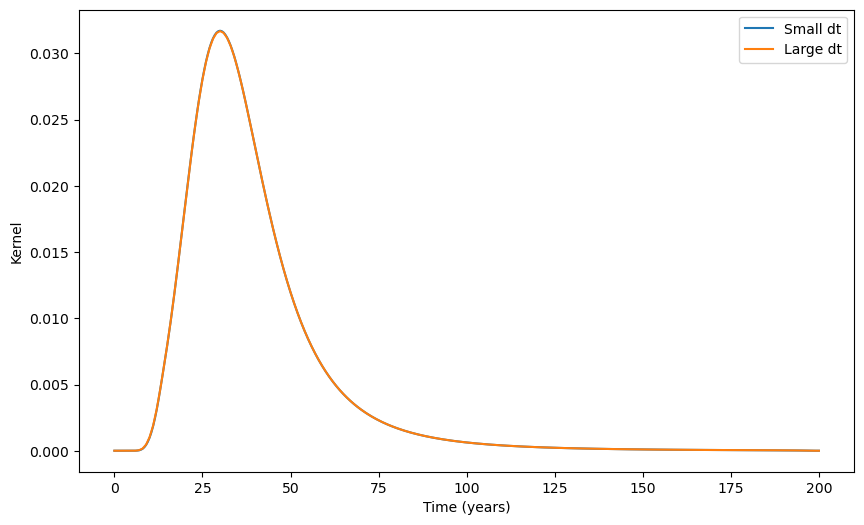

In [12]:
# create a firn filter with different timesteps
t_max = 200
dt_small = 0.5
dt_large = 1
# make a log-logistic function for the filter
fwhm = 27
skew = 0.7
mode = 30

firn_filter_small = FirnFilter.fit_log_logistic(
    fwhm=fwhm,
    skew=skew,
    dt=dt_small,
    mode=mode,
    t_max=t_max
)

firn_filter_large = FirnFilter.fit_log_logistic(
    fwhm=fwhm,
    skew=skew,
    dt=dt_large,
    mode=mode,
    t_max=t_max
)

# plot the filters
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(0, t_max+dt_small, dt_small), firn_filter_small.kernel, label='Small dt')
ax.plot(np.arange(0, t_max+dt_large, dt_large), firn_filter_large.kernel, label='Large dt')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Kernel')
ax.legend()

# helper functions

In [17]:
def effective_kernel(ff, dt_series, tail_mass=0.999, pad_frac=0.25):
    """
    Derive the discrete kernel actually used on the series grid by filtering a delta.
    Returns (h_eff, t_eff, area) where sum(h_eff) ≈ 1 if mass is preserved.
    """
    # Estimate support of the kernel on the series grid
    support_T = len(ff.kernel) * ff.dt
    M_nom = int(np.ceil(support_T / dt_series)) + 1
    M = M_nom + int(pad_frac * M_nom)  # margin for tail

    n = 8 * M + 1
    j0 = n // 2
    x = np.zeros(n)
    x[j0] = 1.0

    y = ff.apply(x, dt_series=dt_series)  # causal => response starts at j0

    h = y[j0:j0 + M].copy()
    h = np.clip(h, 0.0, None)

    # optional tail trim by cumulative mass
    c = np.cumsum(h)
    K = np.searchsorted(c, tail_mass * c[-1])
    if K >= 1:
        h = h[:K+1]

    t = np.arange(h.size) * dt_series
    area = float(h.sum())
    return h, t, area

def freq_response_from_effective(h_eff, dt_series, pad=4):
    H = rfft(h_eff, n=pad * len(h_eff))
    f = rfftfreq(pad * len(h_eff), d=dt_series)   # cycles per time-unit
    return f, np.abs(H)

In [18]:
def check_kernel_area(ff, dt_series, tol=1e-3):
    h, t, area = effective_kernel(ff, dt_series)
    return {"area": area, "pass": abs(area - 1.0) < tol, "h_eff": h, "t_eff": t}

def check_dc_gain(ff, dt_series, N=50000, c=3.2, center_frac=0.8, tol=5e-3):
    x = np.full(N, c)
    y = ff.apply(x, dt_series=dt_series)
    m = int((1 - center_frac) * N / 2)
    sl = slice(m, N - m)
    err = float(abs(y[sl].mean() - c))
    return {"abs_err": err, "pass": err < tol}

def expected_white_var(h_eff, sigma):
    # For unit-area discrete kernel on the series grid
    return float((sigma**2) * np.sum(h_eff**2))

def check_white_variance(ff, dt_series, n=200_000, sigma=2.0, tol_rel=0.05, h_eff=None):
    if h_eff is None:
        h_eff, _, _ = effective_kernel(ff, dt_series)
    x = np.random.default_rng().normal(0.0, sigma, size=n)
    y = ff.apply(x, dt_series=dt_series)
    # avoid edges (if no edge-renorm inside)
    m = n // 10
    sl = slice(m, n - m)
    v_emp = float(np.var(y[sl], ddof=1))
    v_exp = expected_white_var(h_eff, sigma)
    rel = abs(v_emp - v_exp) / max(v_exp, 1e-15)
    return {"emp": v_emp, "exp": v_exp, "rel_err": rel, "pass": rel < tol_rel}

def fit_sine_amplitude(y, t, f):
    s = np.sin(2*np.pi*f*t)
    c = np.cos(2*np.pi*f*t)
    A = np.vstack([s, c]).T
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return float(np.hypot(*coef))  # sqrt(a^2 + b^2)

def check_sine_gain(ff, dt_series, freqs, n_periods=500, tol_rel=0.02, h_eff=None):
    if h_eff is None:
        h_eff, _, _ = effective_kernel(ff, dt_series)
    fH, H = freq_response_from_effective(h_eff, dt_series)
    out = {}
    for f in freqs:
        T = 1.0 / f
        n = int(np.ceil(n_periods * T / dt_series))
        t = np.arange(n) * dt_series
        x = np.sin(2*np.pi*f*t)
        y = ff.apply(x, dt_series=dt_series)
        # measure in center to avoid edge
        m = n // 10
        sl = slice(m, n - m)
        A_emp = fit_sine_amplitude(y[sl], t[sl], f)
        Hf = float(np.interp(f, fH, H))
        rel = abs(A_emp - Hf) / max(Hf, 1e-15)
        out[f] = {"emp": A_emp, "exp": Hf, "rel_err": rel, "pass": rel < tol_rel}
    return out

def check_dt_invariance(ff_short, ff_long, dt_short, dt_long,
                        T=4000.0, freqs=(1/50, 1/200), tol_rmse=2e-2, tol_r=0.999):
    # deterministic signal at two samplings
    t1 = np.arange(0.0, T, dt_short)
    t2 = np.arange(0.0, T, dt_long)
    x1 = sum(np.sin(2*np.pi*f*t1) for f in freqs)
    x2 = sum(np.sin(2*np.pi*f*t2) for f in freqs)

    y1 = ff_short.apply(x1, dt_series=dt_short)
    y2 = ff_long.apply(x2,  dt_series=dt_long)

    # compare on coarse grid
    y1_on_t2 = np.interp(t2, t1, y1)
    rmse = float(np.sqrt(np.mean((y1_on_t2 - y2)**2)))
    r = float(np.corrcoef(y1_on_t2, y2)[0, 1])
    return {"rmse": rmse, "r": r, "pass": (rmse < tol_rmse and r > tol_r)}

def mean_lag_from_effective(h_eff, t_eff):
    return float(np.sum(t_eff * h_eff))

# Checks

In [19]:
# Using your firn_filter_small / firn_filter_large and dt_small / dt_large

# 1) Effective kernels + area
res_s = check_kernel_area(firn_filter_small, dt_small)
res_l = check_kernel_area(firn_filter_large, dt_large)
print("Area (small dt):", res_s["area"], "pass:", res_s["pass"])
print("Area (large dt):", res_l["area"], "pass:", res_l["pass"])

h_s, t_s = res_s["h_eff"], res_s["t_eff"]
h_l, t_l = res_l["h_eff"], res_l["t_eff"]

# 2) DC gain
dc_s = check_dc_gain(firn_filter_small, dt_small)
dc_l = check_dc_gain(firn_filter_large, dt_large)
print("DC gain small:", dc_s)
print("DC gain large:", dc_l)

# 3) White-noise variance scaling
var_s = check_white_variance(firn_filter_small, dt_small, h_eff=h_s)
var_l = check_white_variance(firn_filter_large, dt_large, h_eff=h_l)
print("White var small:", var_s)
print("White var large:", var_l)

# 4) Sinusoid gain at a few frequencies (cycles/yr)
freqs = [1/20, 1/50, 1/200]
gain_s = check_sine_gain(firn_filter_small, dt_small, freqs, h_eff=h_s)
gain_l = check_sine_gain(firn_filter_large, dt_large, freqs, h_eff=h_l)
print("Gain small:", gain_s)
print("Gain large:", gain_l)

# 5) dt invariance on deterministic input
dt_inv = check_dt_invariance(firn_filter_small, firn_filter_large, dt_small, dt_large)
print("dt invariance:", dt_inv)

# 6) Report mean lag (group delay proxy)
mu_s = mean_lag_from_effective(h_s, t_s)
mu_l = mean_lag_from_effective(h_l, t_l)
print(f"Mean lag small: {mu_s:.2f} yr  |  large: {mu_l:.2f} yr  (should be close across dt)")


Area (small dt): 0.9990034644569161 pass: True
Area (large dt): 0.9990436895559077 pass: True
DC gain small: {'abs_err': 4.440892098500626e-16, 'pass': True}
DC gain large: {'abs_err': 4.440892098500626e-16, 'pass': True}
White var small: {'emp': 0.04001421593457076, 'exp': 0.04123840738948779, 'rel_err': 0.029685711268012976, 'pass': True}
White var large: {'emp': 0.08119859973159291, 'exp': 0.0824105261192472, 'rel_err': 0.014705965909022843, 'pass': True}
Gain small: {0.05: {'emp': 0.01243238183397949, 'exp': 0.012606017634102396, 'rel_err': 0.013774040713157321, 'pass': True}, 0.02: {'emp': 0.31629443467165647, 'exp': 0.31616850067034163, 'rel_err': 0.00039831292822601114, 'pass': True}, 0.005: {'emp': 0.8653226013134849, 'exp': 0.8651736525194217, 'rel_err': 0.00017216057565957608, 'pass': True}}
Gain large: {0.05: {'emp': 0.012302536012229033, 'exp': 0.012482268122292566, 'rel_err': 0.014398994501851996, 'pass': True}, 0.02: {'emp': 0.3157852016055125, 'exp': 0.3156146163383546, 